In [1]:
# Import RealTestDataGenerator
from pyphysio.generators import RealTestDataGenerator

Using dask. Scheduler: threads
Please cite:
Bizzego et al. (2019) 'pyphysio: A physiological signal processing library for data science approaches in physiology', SoftwareX
4.1-beta


# PyPhysio Signal Generators Tutorial

This notebook demonstrates how to use the PyPhysio signal generators to create various physiological and fundamental signals with realistic characteristics.

## Overview

PyPhysio provides comprehensive signal generation capabilities for:
- **Basic Signals**: Sinusoidal, noise, fundamental patterns
- **Physiological Signals**: ECG, respiration, EDA, BVP, fNIRS, EEG, EMG
- **Advanced Processing**: Signal composition, windowing, modulation

All signals are returned as xarray.DataArray with metadata and timing information.

In [2]:
# Import Required Libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import sys

# Set matplotlib style for better plots
plt.style.use('seaborn-v0_8-darkgrid')

# Import PyPhysio Signal Generators
from pyphysio.generators import (
    ECGGenerator,
    RespirationGenerator,
    EDAGenerator,
    fNIRSGenerator,
    EEGGenerator,
    EMGGenerator,
    BloodVolumePulseGenerator,
    SinusoidalGenerator,
    NoiseGenerator,
    FundamentalSignalGenerator,
    CompositeSignalGenerator,
    WindowGenerator,
    SawtoothGenerator,
    GaussianComponentGenerator,
    PolynomialGenerator
)

print("✓ All generators imported successfully")

✓ All generators imported successfully


## 1. Basic Sinusoidal Signals

Let's start with simple sine waves at different frequencies and a multi-component signal.

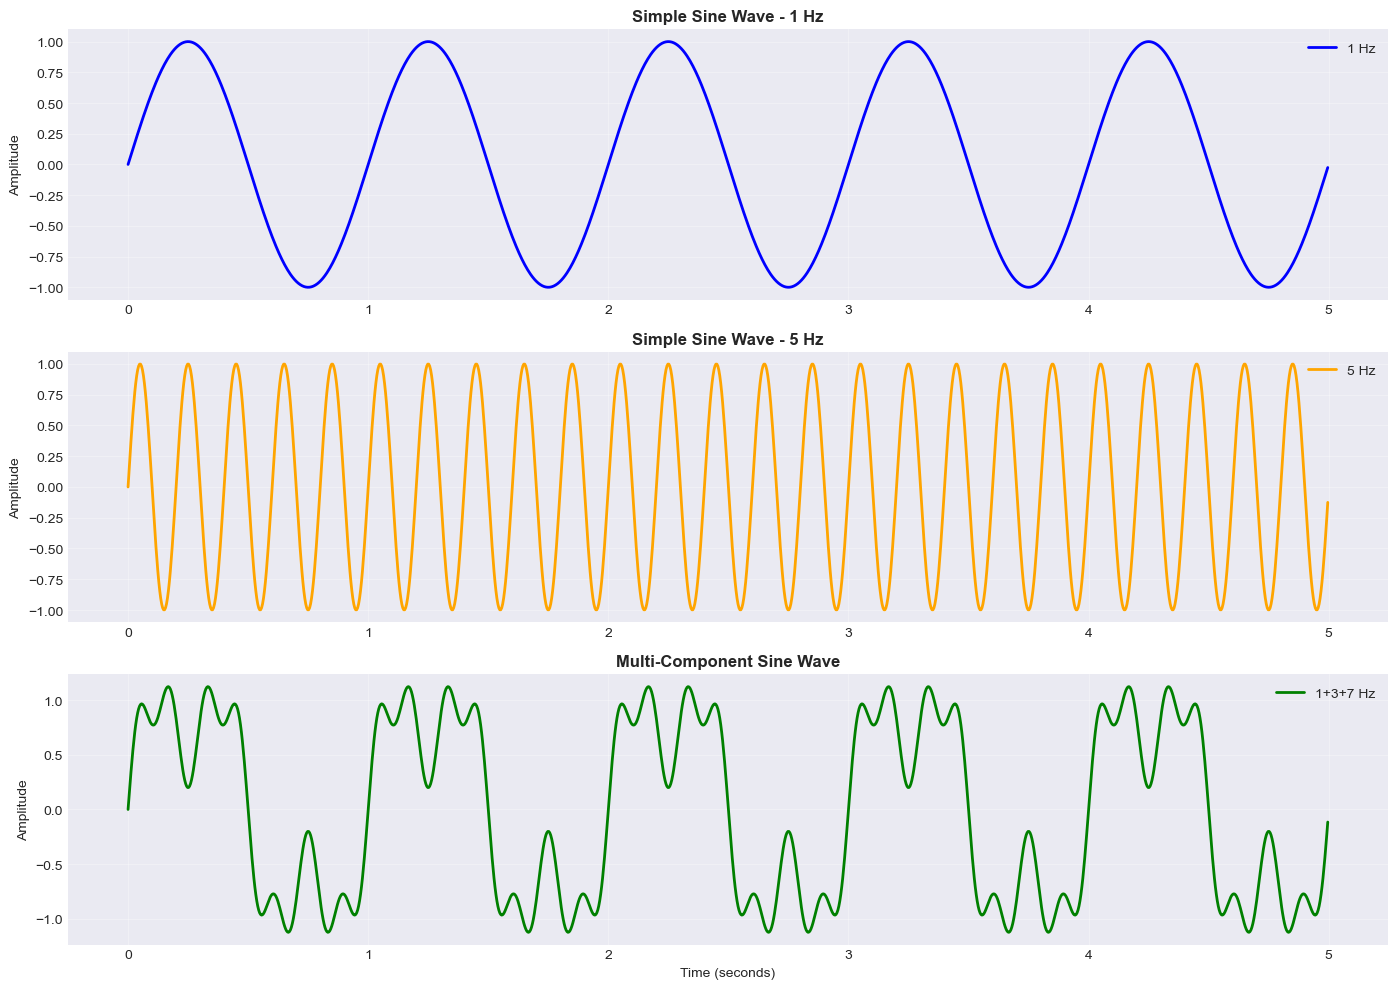

✓ Generated 1250 samples at 250 Hz for each signal


In [3]:
# Generate sinusoidal signals
sine_1hz = SinusoidalGenerator.simple_sine(
    duration=5, 
    sampling_freq=250, 
    amplitude=1.0,
    frequency=1.0
)

sine_5hz = SinusoidalGenerator.simple_sine(
    duration=5,
    sampling_freq=250,
    amplitude=1.0,
    frequency=5.0
)

# Multi-component sine (1 Hz + 3 Hz + 7 Hz)
sine_multi = SinusoidalGenerator.multi_component_sine(
    duration=5,
    sampling_freq=250,
    components=[
        {'frequency': 1.0, 'amplitude': 1.0},
        {'frequency': 3.0, 'amplitude': 0.5},
        {'frequency': 7.0, 'amplitude': 0.3}
    ]
)

# Visualize
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(sine_1hz.time, sine_1hz.values, linewidth=2, label='1 Hz', color='blue')
axes[0].set_title('Simple Sine Wave - 1 Hz', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Amplitude')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(sine_5hz.time, sine_5hz.values, linewidth=2, label='5 Hz', color='orange')
axes[1].set_title('Simple Sine Wave - 5 Hz', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Amplitude')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(sine_multi.time, sine_multi.values, linewidth=2, label='1+3+7 Hz', color='green')
axes[2].set_title('Multi-Component Sine Wave', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Amplitude')
axes[2].set_xlabel('Time (seconds)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✓ Generated {len(sine_1hz)} samples at 250 Hz for each signal")

## 2. Noise Signals

Different types of noise are essential for simulating realistic measurements and testing signal processing algorithms.

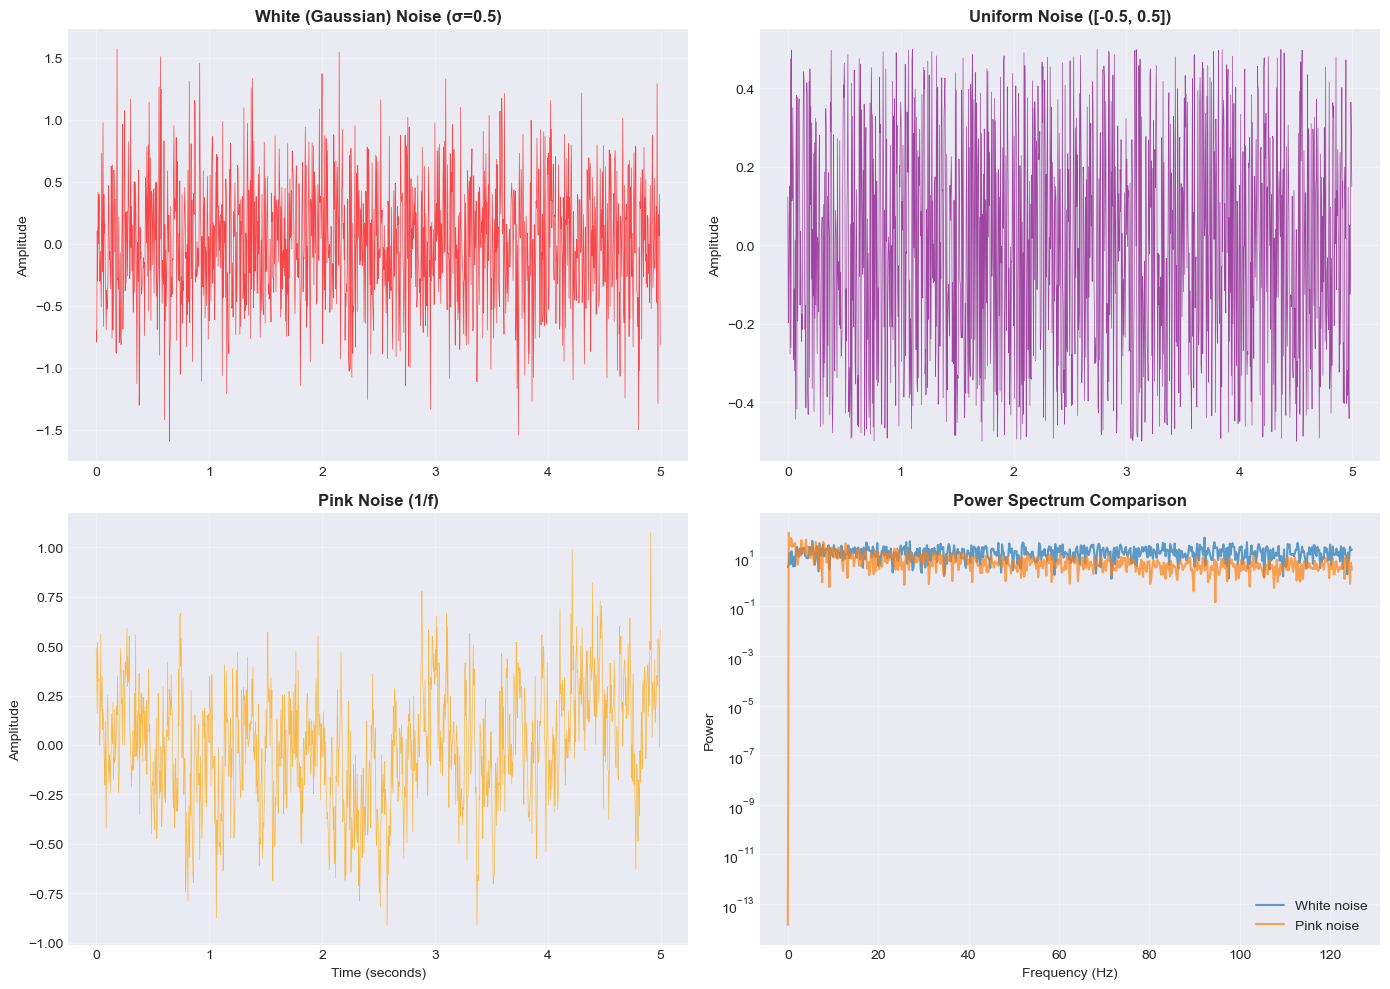

White noise: mean=0.003, std=0.509
Pink noise: mean=0.000, std=0.300


In [4]:
# Generate different noise types
white_noise = NoiseGenerator.white_noise(duration=5, sampling_freq=250, std=0.5)
uniform_noise = NoiseGenerator.uniform_noise(duration=5, sampling_freq=250, low=-0.5, high=0.5)
pink_noise = NoiseGenerator.pink_noise(duration=5, sampling_freq=250, std=0.3)

# Visualize noise types
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(white_noise.time, white_noise.values, linewidth=0.5, alpha=0.7, color='red')
axes[0, 0].set_title('White (Gaussian) Noise (σ=0.5)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(uniform_noise.time, uniform_noise.values, linewidth=0.5, alpha=0.7, color='purple')
axes[0, 1].set_title('Uniform Noise ([-0.5, 0.5])', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Amplitude')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(pink_noise.time, pink_noise.values, linewidth=0.5, alpha=0.7, color='orange')
axes[1, 0].set_title('Pink Noise (1/f)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Amplitude')
axes[1, 0].set_xlabel('Time (seconds)')
axes[1, 0].grid(True, alpha=0.3)

# Power spectrum comparison
from scipy.fft import fft, fftfreq
freqs = fftfreq(len(white_noise), 1/250)[:len(white_noise)//2]
axes[1, 1].semilogy(freqs, np.abs(fft(white_noise.values))[:len(white_noise)//2], 
                    label='White noise', alpha=0.7)
axes[1, 1].semilogy(freqs, np.abs(fft(pink_noise.values))[:len(pink_noise)//2], 
                    label='Pink noise', alpha=0.7)
axes[1, 1].set_title('Power Spectrum Comparison', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Frequency (Hz)')
axes[1, 1].set_ylabel('Power')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"White noise: mean={white_noise.values.mean():.3f}, std={white_noise.values.std():.3f}")
print(f"Pink noise: mean={pink_noise.values.mean():.3f}, std={pink_noise.values.std():.3f}")

## 3. ECG (Electrocardiogram) Signals

Generate realistic ECG signals with heart rate variability and ectopic beats.

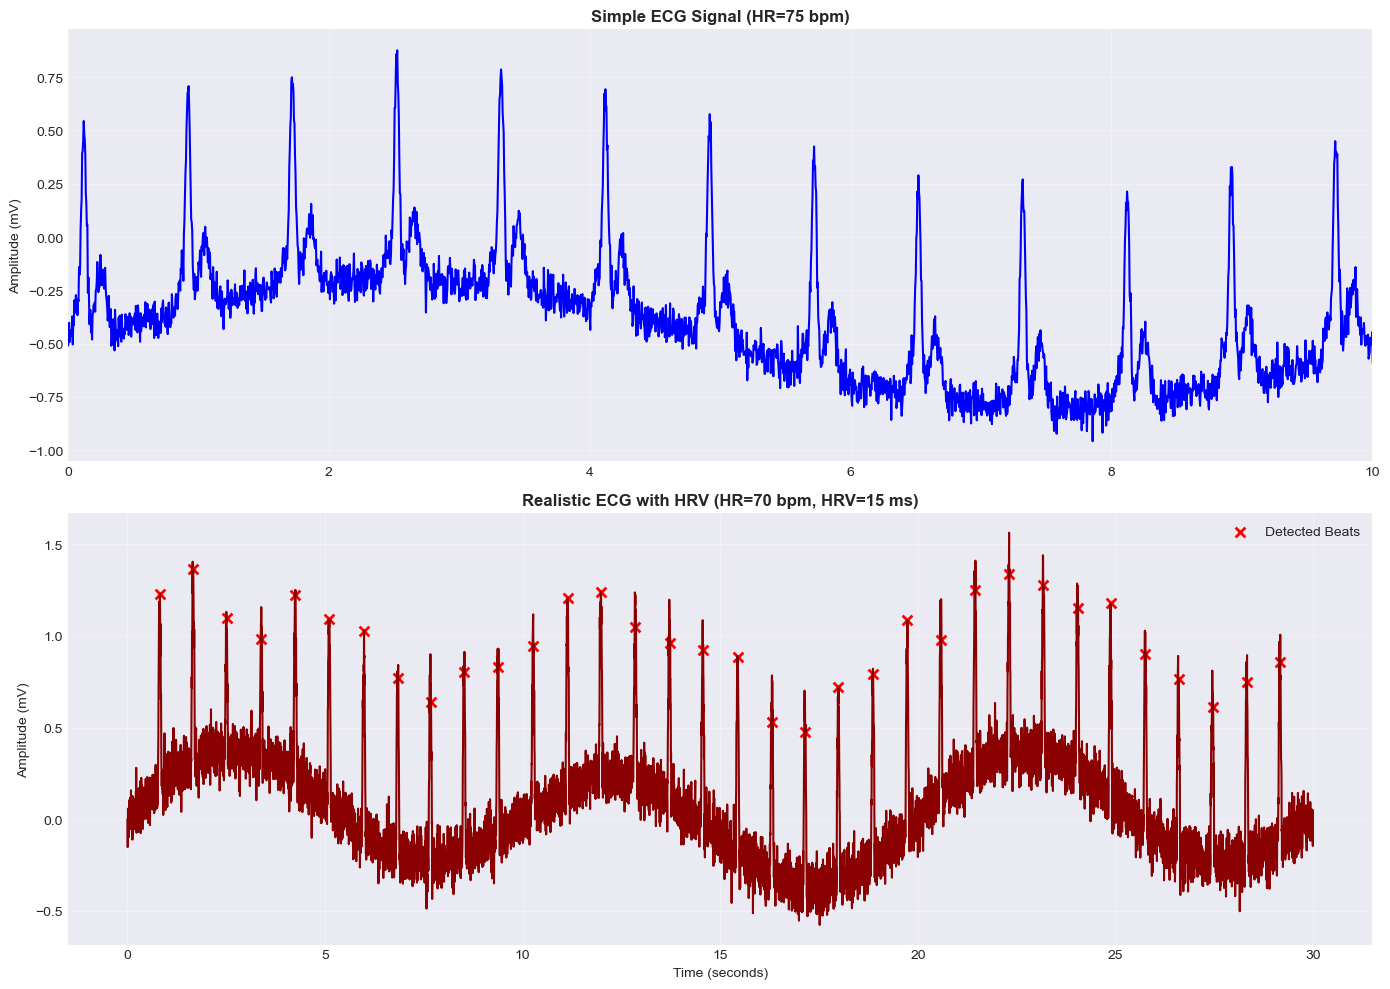

Simple ECG: 5000 samples
Realistic ECG: 34 detected beats


In [5]:
# Simple ECG
simple_ecg = ECGGenerator.simple_ecg(
    duration=20,
    sampling_freq=250,
    heart_rate=75,
    noise_std=0.05
)

# Realistic ECG with variability
realistic_ecg = ECGGenerator.realistic_ecg(
    duration=30,
    sampling_freq=250,
    heart_rate=70,
    heart_rate_variability=15,
    noise_std=0.08,
    ectopy_rate=0.05
)

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(simple_ecg.time, simple_ecg.values, linewidth=1.5, color='blue')
axes[0].set_title(f'Simple ECG Signal (HR={simple_ecg.attrs["heart_rate"]} bpm)', 
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Amplitude (mV)')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, 10])

axes[1].plot(realistic_ecg.time, realistic_ecg.values, linewidth=1.5, color='darkred')
beat_times = realistic_ecg.attrs['beat_times']
beat_indices = np.searchsorted(realistic_ecg.time.values, beat_times)
beat_indices = beat_indices[beat_indices < len(realistic_ecg)]
if len(beat_indices) > 0:
    beat_amplitudes = realistic_ecg.values[beat_indices]
    axes[1].scatter(beat_times[:len(beat_amplitudes)], beat_amplitudes, 
                   color='red', s=50, marker='x', linewidth=2, label='Detected Beats')

axes[1].set_title(f'Realistic ECG with HRV (HR={realistic_ecg.attrs["heart_rate"]} bpm, HRV={realistic_ecg.attrs["heart_rate_variability"]} ms)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Amplitude (mV)')
axes[1].set_xlabel('Time (seconds)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Simple ECG: {len(simple_ecg)} samples")
print(f"Realistic ECG: {len(beat_times)} detected beats")

## 4. Respiration Signals

Create sinusoidal and realistic respiration patterns with respiratory sinus arrhythmia.

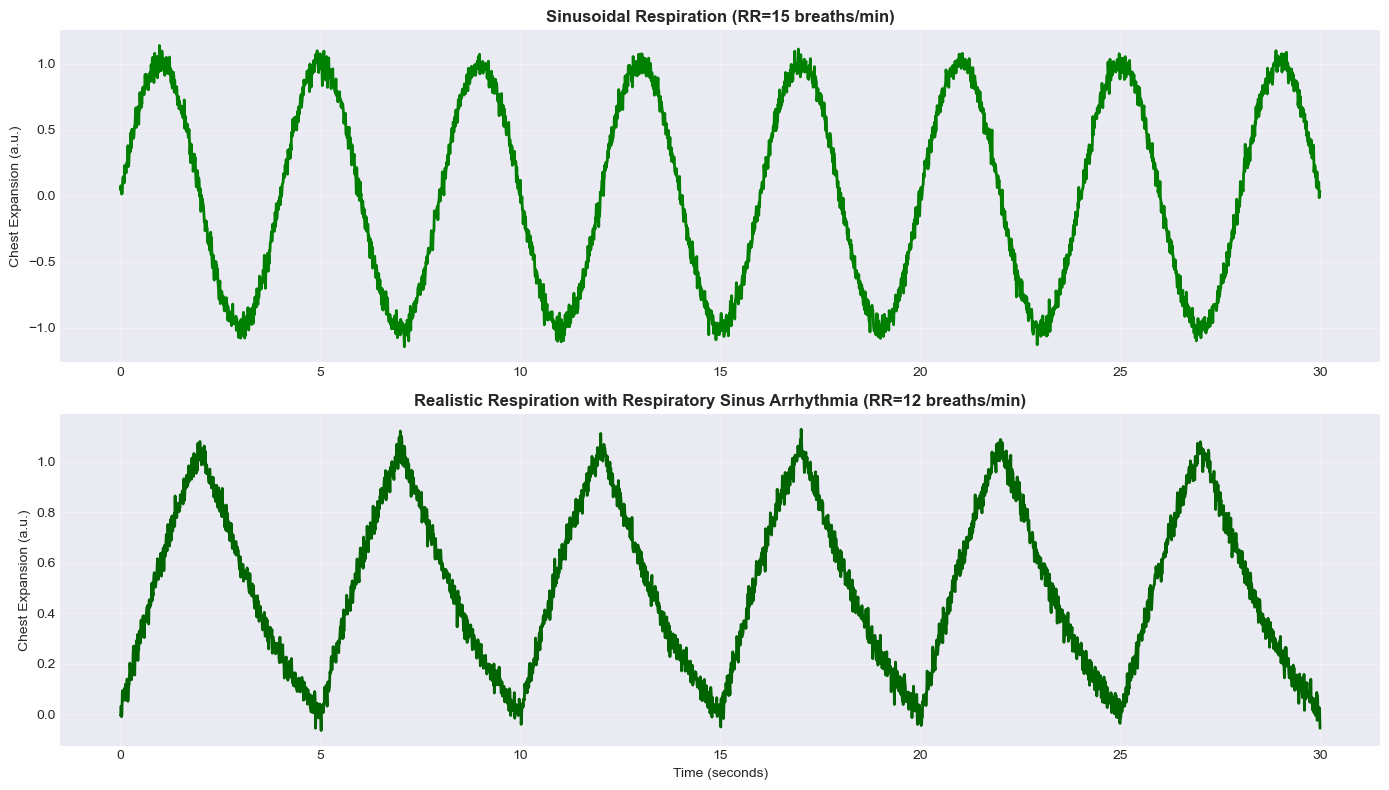

In [6]:
# Sinusoidal respiration
sine_resp = RespirationGenerator.sinusoidal_respiration(
    duration=30,
    sampling_freq=100,
    respiration_rate=15,
    amplitude=1.0,
    noise_std=0.05
)

# Realistic respiration with asymmetric inspiration/expiration
realistic_resp = RespirationGenerator.realistic_respiration(
    duration=30,
    sampling_freq=100,
    respiration_rate=12,
    amplitude=1.0,
    inspiration_expiration_ratio=0.4,
    respiratory_sinus_arrhythmia=True,
    noise_std=0.03
)

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(sine_resp.time, sine_resp.values, linewidth=2, color='green')
axes[0].set_title(f'Sinusoidal Respiration (RR={sine_resp.attrs["respiration_rate"]} breaths/min)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Chest Expansion (a.u.)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(realistic_resp.time, realistic_resp.values, linewidth=2, color='darkgreen')
axes[1].set_title('Realistic Respiration with Respiratory Sinus Arrhythmia (RR=12 breaths/min)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Chest Expansion (a.u.)')
axes[1].set_xlabel('Time (seconds)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. EDA (Electrodermal Activity) Signals

Generate EDA signals with stimulus-induced phasic responses using the Bateman function.

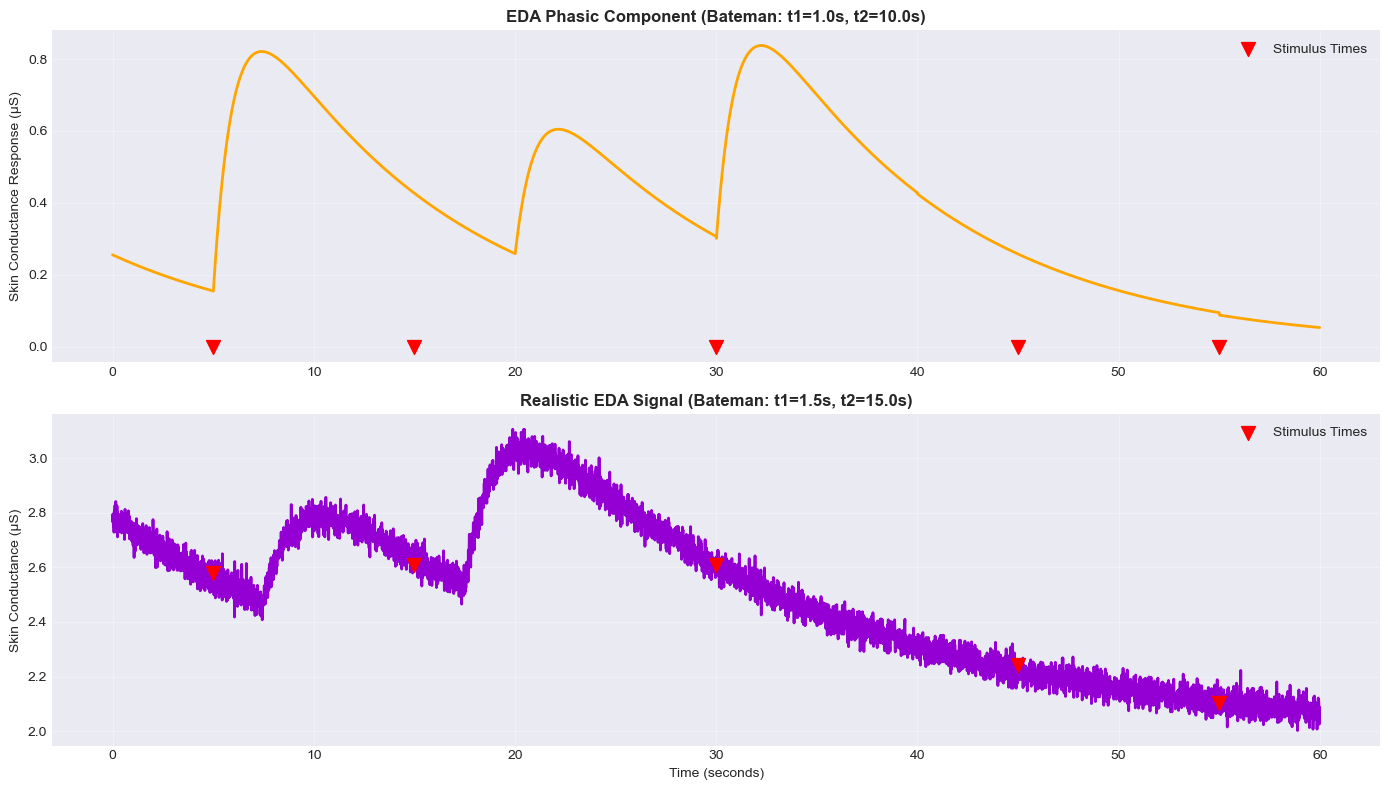

EDA Phasic peak: 0.838 µS
EDA Realistic range: 2.002 - 3.106 µS


In [7]:
# Define stimulus times and magnitudes
stimulus_times = [5, 15, 30, 45, 55]
stimulus_magnitudes = [0.5, 0.3, 0.7, 0.4, 0.6]

# EDA phasic component
eda_phasic = EDAGenerator.eda_phasic_component(
    duration=60,
    sampling_freq=100,
    stimulus_times=stimulus_times,
    response_magnitude=stimulus_magnitudes,
    t1=1.0,      # Rise time constant (seconds)
    t2=10.0      # Recovery time constant (seconds)
)

# Realistic EDA with combined tonic and phasic
eda_realistic = EDAGenerator.realistic_eda(
    duration=60,
    sampling_freq=100,
    base_scl=2.0,
    stimulus_times=stimulus_times,
    stimulus_magnitudes=stimulus_magnitudes,
    noise_std=0.03,
    t1=1.5,
    t2=15.0
)

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(eda_phasic.time, eda_phasic.values, linewidth=2, color='orange')
axes[0].scatter(stimulus_times, [0]*len(stimulus_times), color='red', s=100, marker='v', 
               label='Stimulus Times', zorder=5)
axes[0].set_title('EDA Phasic Component (Bateman: t1=1.0s, t2=10.0s)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Skin Conductance Response (µS)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(eda_realistic.time, eda_realistic.values, linewidth=2, color='darkviolet')
axes[1].scatter(stimulus_times, [eda_realistic.values[int(t*100)] for t in stimulus_times],
               color='red', s=100, marker='v', label='Stimulus Times', zorder=5)
axes[1].set_title('Realistic EDA Signal (Bateman: t1=1.5s, t2=15.0s)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Skin Conductance (µS)')
axes[1].set_xlabel('Time (seconds)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"EDA Phasic peak: {eda_phasic.values.max():.3f} µS")
print(f"EDA Realistic range: {eda_realistic.values.min():.3f} - {eda_realistic.values.max():.3f} µS")

## 6. Blood Volume Pulse (BVP) and Pulse Oximetry

Generate BVP and SpO2 signals with realistic variations.

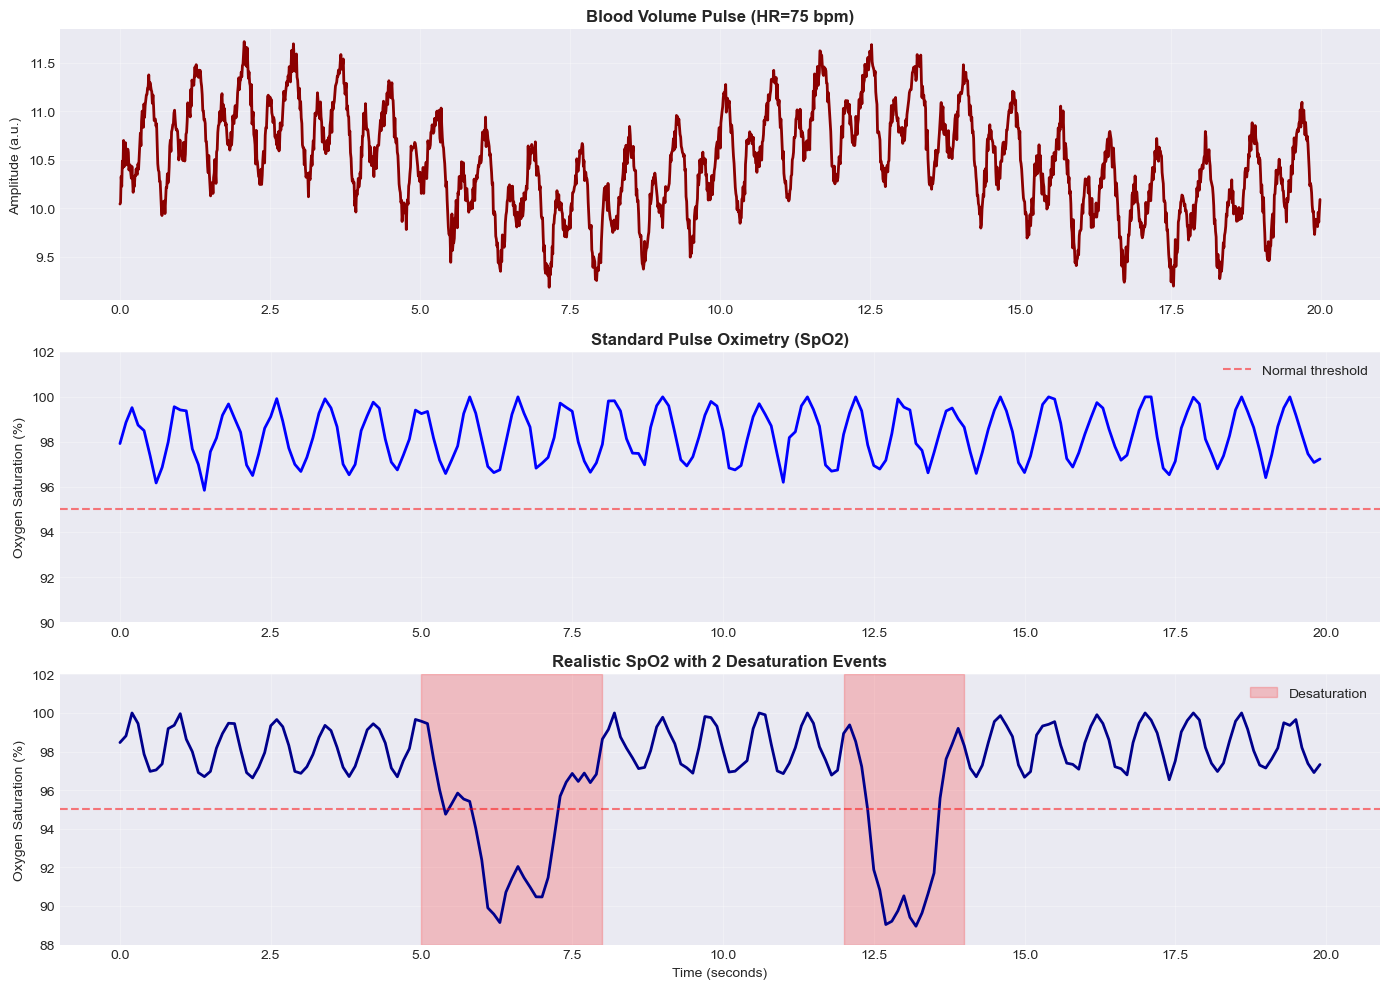

In [8]:
# Blood Volume Pulse
bvp_sig = BloodVolumePulseGenerator.bvp_signal(
    duration=20,
    sampling_freq=100,
    heart_rate=75,
    amplitude=1.0,
    systolic_diastolic_ratio=0.6,
    noise_std=0.08
)

# Pulse Oximetry
spo2_sig = BloodVolumePulseGenerator.pulse_oximetry_signal(
    duration=20,
    sampling_freq=10,
    heart_rate=75,
    spo2=98.0,
    noise_std=0.3
)

# Realistic SpO2 with desaturation events
desaturation_events = [(5, 8, 0.08), (12, 14, 0.10)]
spo2_realistic = BloodVolumePulseGenerator.realistic_pulse_oximetry(
    duration=20,
    sampling_freq=10,
    heart_rate=75,
    spo2_events=desaturation_events,
    event_severity=0.08,
    noise_std=0.3
)

# Visualize
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(bvp_sig.time, bvp_sig.values, linewidth=2, color='darkred')
axes[0].set_title(f'Blood Volume Pulse (HR={bvp_sig.attrs["heart_rate"]} bpm)', 
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Amplitude (a.u.)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(spo2_sig.time, spo2_sig.values, linewidth=2, color='blue')
axes[1].axhline(y=95, color='red', linestyle='--', alpha=0.5, label='Normal threshold')
axes[1].set_title('Standard Pulse Oximetry (SpO2)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Oxygen Saturation (%)')
axes[1].set_ylim([90, 102])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(spo2_realistic.time, spo2_realistic.values, linewidth=2, color='darkblue')
for event_start, event_end, depth in desaturation_events:
    axes[2].axvspan(event_start, event_end, alpha=0.2, color='red', 
                   label='Desaturation' if event_start == desaturation_events[0][0] else '')
axes[2].axhline(y=95, color='red', linestyle='--', alpha=0.5)
axes[2].set_title(f'Realistic SpO2 with {len(desaturation_events)} Desaturation Events', 
                  fontsize=12, fontweight='bold')
axes[2].set_ylabel('Oxygen Saturation (%)')
axes[2].set_xlabel('Time (seconds)')
axes[2].set_ylim([88, 102])
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. fNIRS (Functional Near-Infrared Spectroscopy) Signals

Generate hemodynamic responses measured by fNIRS systems.

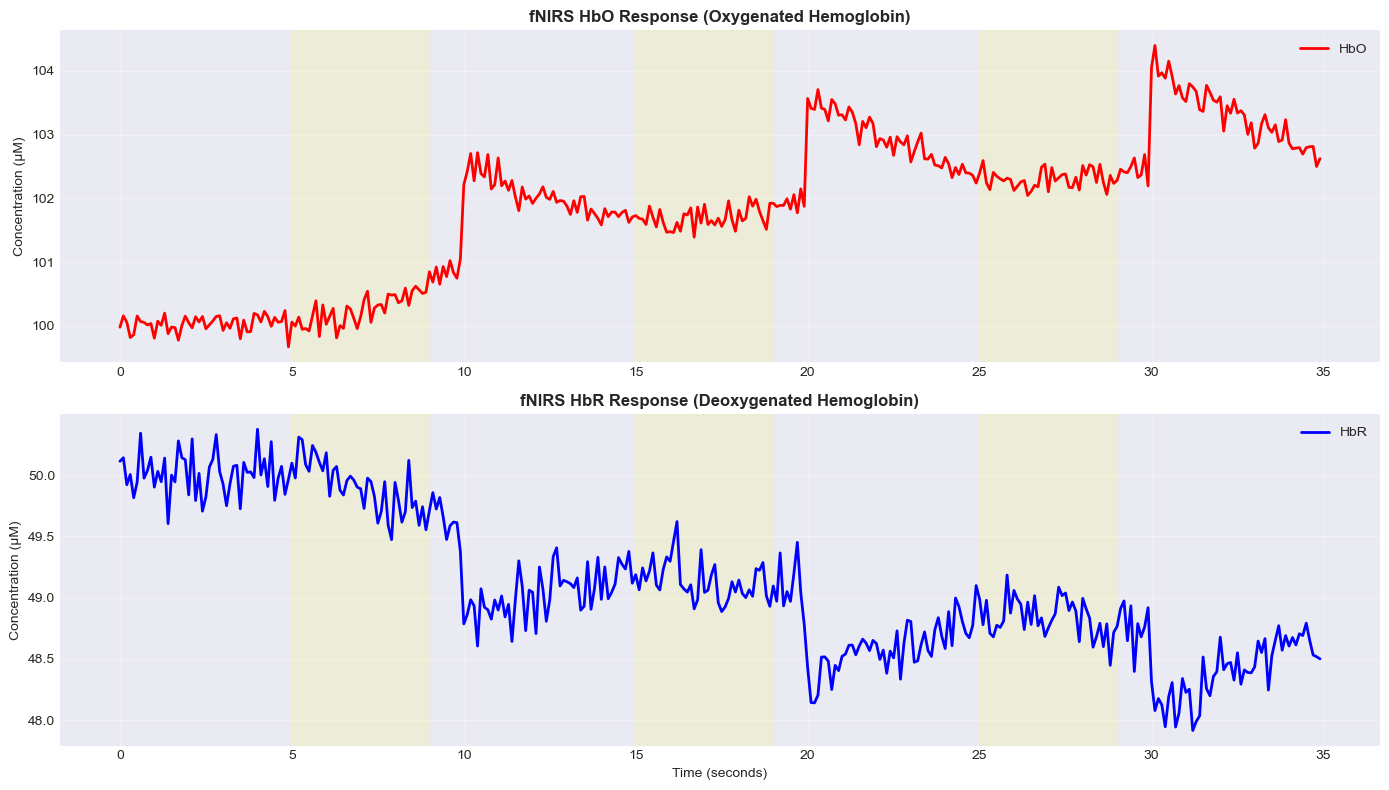

HbO: baseline=101.82 µM, peak=104.40 µM
HbR: baseline=49.12 µM, minimum=47.92 µM


In [9]:
# fNIRS stimulus response
stimulus_times = [5, 15, 25]
stimulus_duration = 4.0

hbo, hbr = fNIRSGenerator.hbo_hbr_response(
    duration=35,
    sampling_freq=10,
    stimulus_times=stimulus_times,
    stimulus_duration=stimulus_duration,
    hbo_magnitude=2.5,
    hbr_magnitude=-1.2,
    rise_time=1.0,
    peak_time=5.0,
    recovery_time=12.0,
    noise_std=0.15
)

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(hbo.time, hbo.values, linewidth=2, color='red', label='HbO')
for stim_time in stimulus_times:
    axes[0].axvspan(stim_time, stim_time + stimulus_duration, alpha=0.1, color='yellow')
axes[0].set_title('fNIRS HbO Response (Oxygenated Hemoglobin)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Concentration (µM)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(hbr.time, hbr.values, linewidth=2, color='blue', label='HbR')
for stim_time in stimulus_times:
    axes[1].axvspan(stim_time, stim_time + stimulus_duration, alpha=0.1, color='yellow')
axes[1].set_title('fNIRS HbR Response (Deoxygenated Hemoglobin)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Concentration (µM)')
axes[1].set_xlabel('Time (seconds)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"HbO: baseline={hbo.values.mean():.2f} µM, peak={hbo.values.max():.2f} µM")
print(f"HbR: baseline={hbr.values.mean():.2f} µM, minimum={hbr.values.min():.2f} µM")

## 8. EEG (Electroencephalography) Signals

Generate EEG signals with mixed frequency bands and alpha bursts.

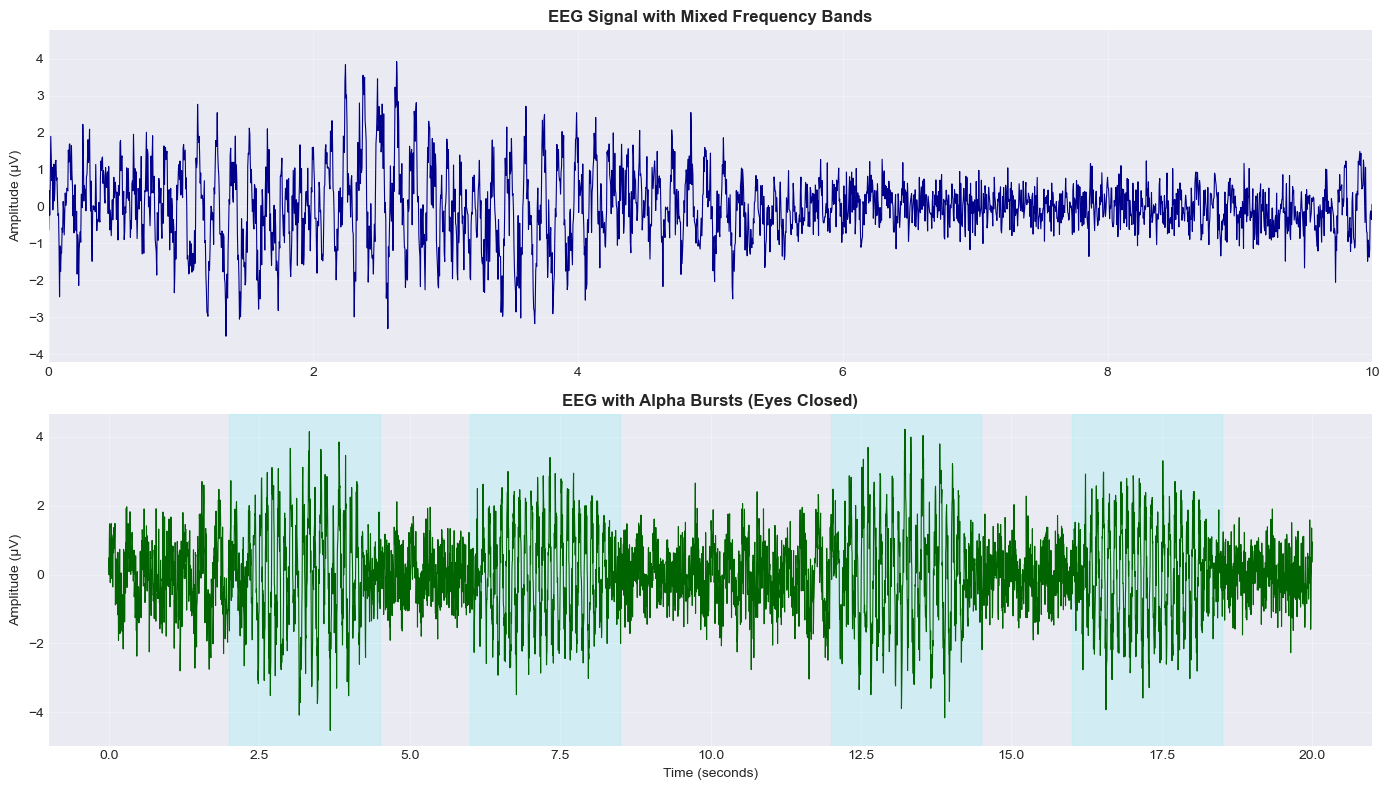

Mixed bands EEG: 5120 samples at 256 Hz
Alpha burst EEG: 4 bursts detected


In [10]:
# EEG with mixed frequency bands
eeg_mixed = EEGGenerator.eeg_with_bands(
    duration=20,
    sampling_freq=256,
    delta_power=0.3,
    theta_power=0.8,
    alpha_power=1.5,
    beta_power=0.9,
    gamma_power=0.3,
    noise_std=0.4
)

# EEG with alpha bursts (eyes closed)
burst_times = [2, 6, 12, 16]
eeg_alpha = EEGGenerator.eeg_alpha_burst(
    duration=20,
    sampling_freq=256,
    burst_times=burst_times,
    burst_duration=2.5,
    alpha_freq=10.0,
    alpha_amplitude=2.0,
    background_power=0.5,
    noise_std=0.4
)

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(eeg_mixed.time, eeg_mixed.values, linewidth=0.8, color='darkblue')
axes[0].set_title('EEG Signal with Mixed Frequency Bands', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Amplitude (µV)')
axes[0].set_xlim([0, 10])
axes[0].grid(True, alpha=0.3)

axes[1].plot(eeg_alpha.time, eeg_alpha.values, linewidth=0.8, color='darkgreen')
for burst_time in burst_times:
    axes[1].axvspan(burst_time, burst_time + 2.5, alpha=0.1, color='cyan')
axes[1].set_title('EEG with Alpha Bursts (Eyes Closed)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Amplitude (µV)')
axes[1].set_xlabel('Time (seconds)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mixed bands EEG: {len(eeg_mixed)} samples at 256 Hz")
print(f"Alpha burst EEG: {len(burst_times)} bursts detected")

## 9. EMG (Electromyography) Signals

Generate EMG signals during rest and muscle contraction.

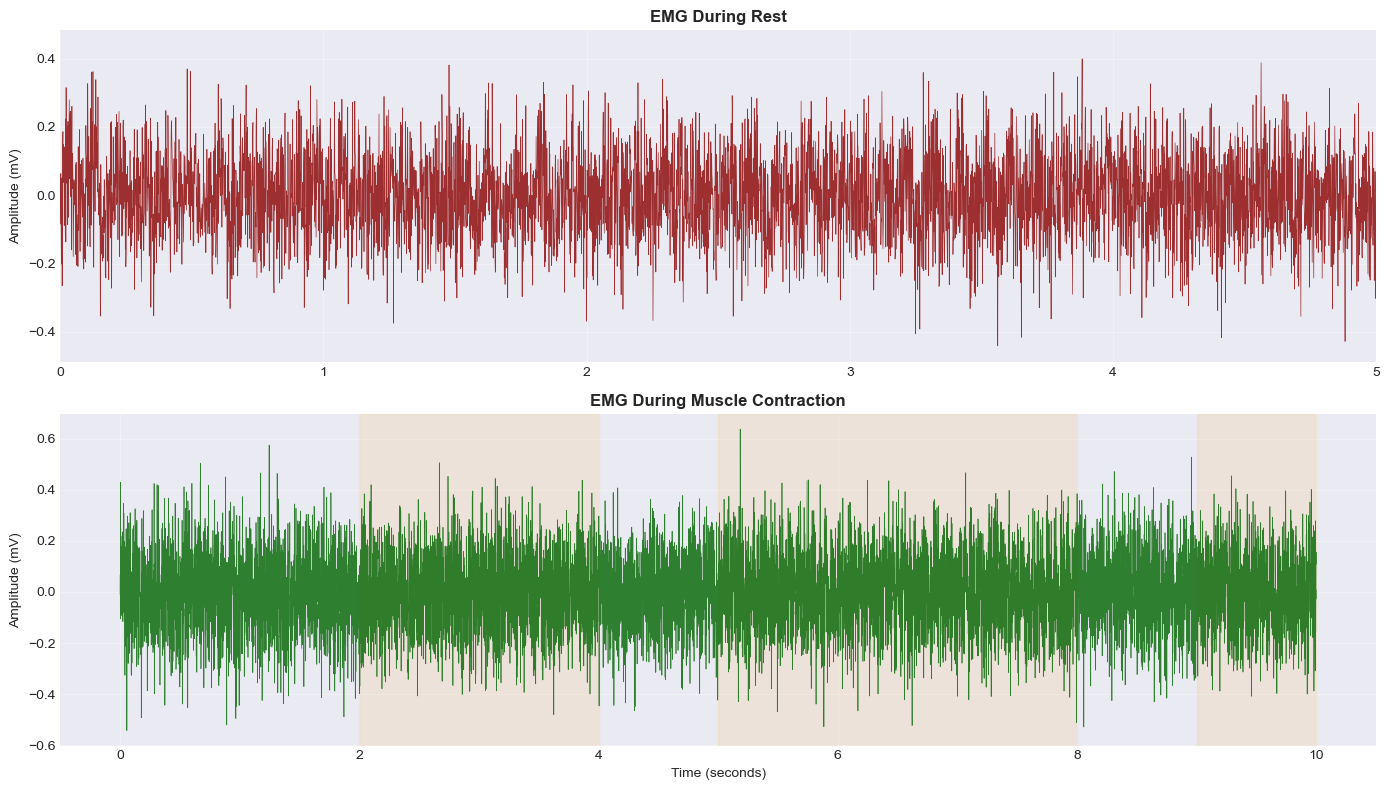

Resting EMG: baseline activity = -0.0030 mV
Contraction EMG: 3 contraction intervals


In [11]:
# Resting EMG
emg_rest = EMGGenerator.emg_at_rest(
    duration=10,
    sampling_freq=1000,
    baseline_activity=0.08,
    noise_std=0.12
)

# EMG during contraction
contraction_intervals = [(2, 4), (5, 8), (9, 10)]
emg_contract = EMGGenerator.emg_during_contraction(
    duration=10,
    sampling_freq=1000,
    contraction_times=contraction_intervals,
    contraction_force=0.7,
    noise_std=0.15
)

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(emg_rest.time, emg_rest.values, linewidth=0.5, color='darkred', alpha=0.8)
axes[0].set_title('EMG During Rest', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Amplitude (mV)')
axes[0].set_xlim([0, 5])
axes[0].grid(True, alpha=0.3)

axes[1].plot(emg_contract.time, emg_contract.values, linewidth=0.5, color='darkgreen', alpha=0.8)
for start, end in contraction_intervals:
    axes[1].axvspan(start, end, alpha=0.1, color='orange')
axes[1].set_title('EMG During Muscle Contraction', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Amplitude (mV)')
axes[1].set_xlabel('Time (seconds)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Resting EMG: baseline activity = {emg_rest.values.mean():.4f} mV")
print(f"Contraction EMG: {len(contraction_intervals)} contraction intervals")

## 10. Composite Signal Processing

Demonstrate advanced signal processing techniques including noise addition, artifact injection, and windowing.

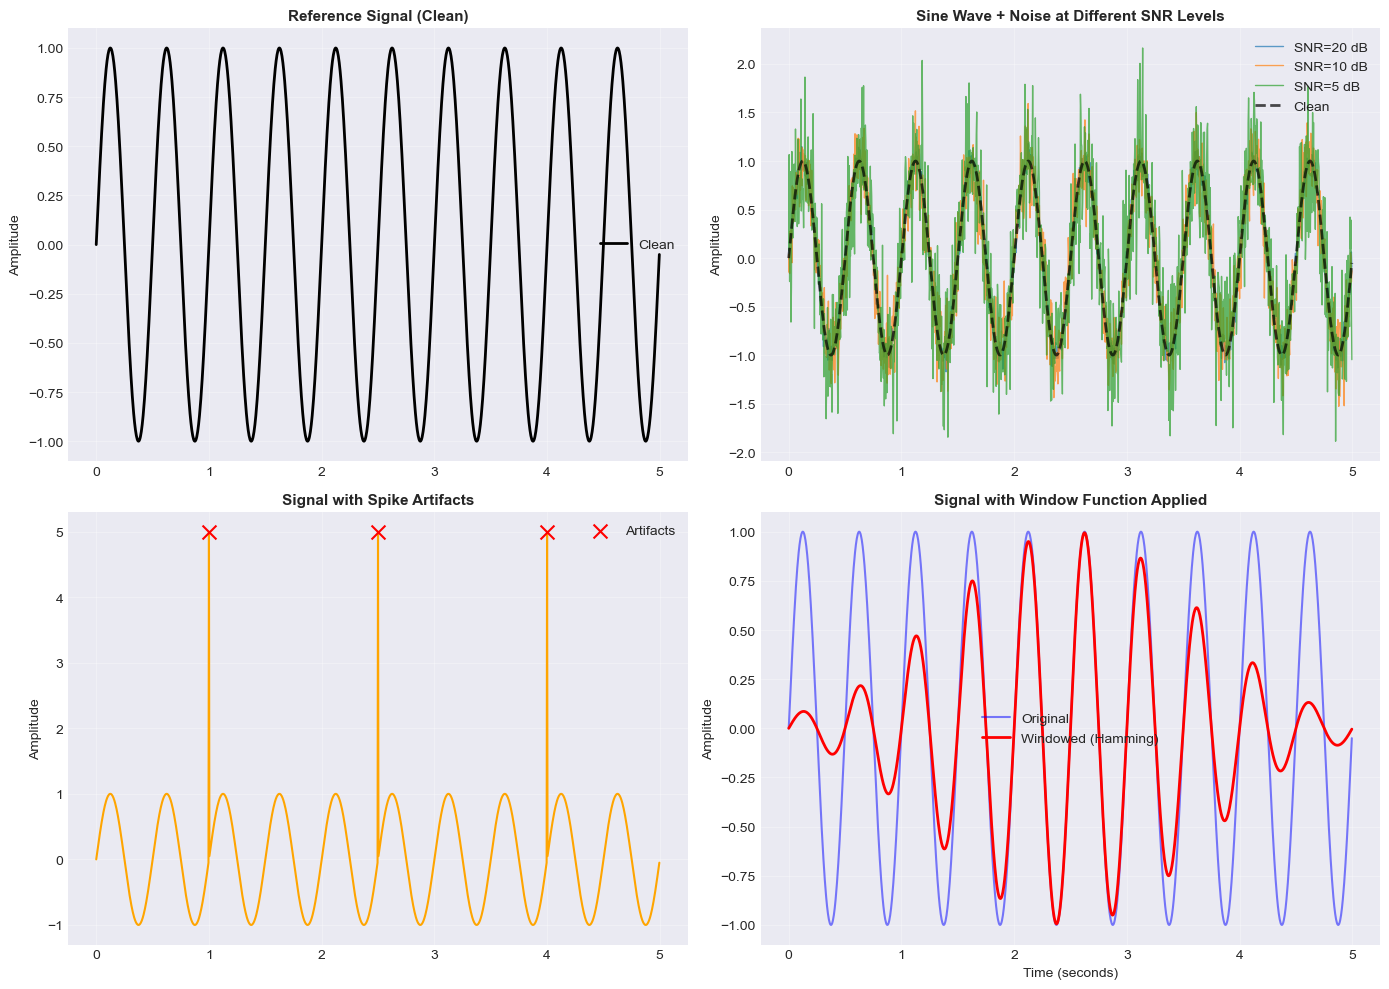

✓ Composite signal processing demonstrated


In [12]:
# Create a clean reference signal
clean_sine = SinusoidalGenerator.simple_sine(
    duration=5,
    sampling_freq=250,
    amplitude=1.0,
    frequency=2.0
)

# Add different SNR levels
snr_levels = [20, 10, 5]
noisy_signals = [CompositeSignalGenerator.signal_with_noise(clean_sine, snr_db=snr) 
                for snr in snr_levels]

# Create signal with artifacts
artifact_times = [1.0, 2.5, 4.0]
sig_artifacts = CompositeSignalGenerator.signal_with_artifacts(
    clean_sine, artifact_times, artifact_type='spike', artifact_amplitude=5.0
)

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Clean signal
axes[0, 0].plot(clean_sine.time, clean_sine.values, linewidth=2, color='black', label='Clean')
axes[0, 0].set_title('Reference Signal (Clean)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Different SNR levels
for idx, (snr, noisy_sig) in enumerate(zip(snr_levels, noisy_signals)):
    axes[0, 1].plot(noisy_sig.time, noisy_sig.values, linewidth=1, alpha=0.7, label=f'SNR={snr} dB')
axes[0, 1].plot(clean_sine.time, clean_sine.values, linewidth=2, linestyle='--', 
               color='black', alpha=0.7, label='Clean')
axes[0, 1].set_title('Sine Wave + Noise at Different SNR Levels', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Amplitude')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Signal with artifacts
axes[1, 0].plot(sig_artifacts.time, sig_artifacts.values, linewidth=1.5, color='orange')
axes[1, 0].scatter(artifact_times, [sig_artifacts.values[int(t*250)] for t in artifact_times], 
                   color='red', s=100, marker='x', zorder=5, label='Artifacts')
axes[1, 0].set_title('Signal with Spike Artifacts', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Amplitude')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Windowed signal
windowed = WindowGenerator.apply_window(clean_sine, window_type='hamming')
axes[1, 1].plot(clean_sine.time, clean_sine.values, linewidth=1.5, alpha=0.5, 
               label='Original', color='blue')
axes[1, 1].plot(windowed.time, windowed.values, linewidth=2, label='Windowed (Hamming)', color='red')
axes[1, 1].set_title('Signal with Window Function Applied', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Amplitude')
axes[1, 1].set_xlabel('Time (seconds)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Composite signal processing demonstrated")

## 11. Advanced Signal Generation

Demonstrate sawtooth waves, Gaussian components, polynomial signals, and frequency sweeps.

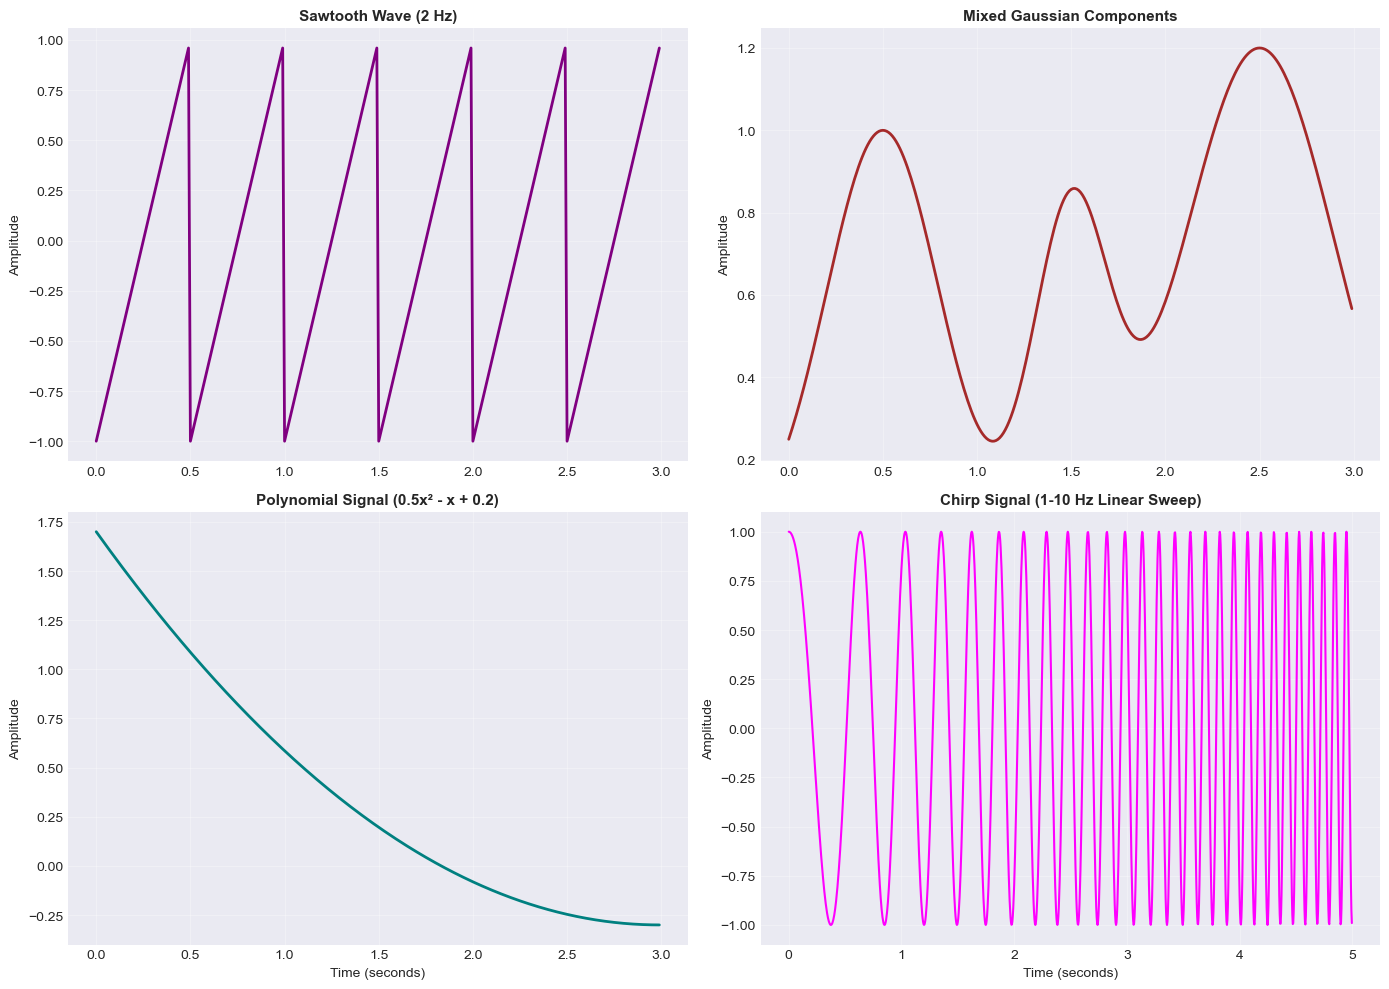

✓ Advanced signal generators demonstrated


In [13]:
# Sawtooth wave
sawtooth_sig = SawtoothGenerator.sawtooth(
    duration=3,
    sampling_freq=100,
    frequency=2.0,
    amplitude=1.0,
    width=1.0
)

# Mixed Gaussians
mixed_gauss = GaussianComponentGenerator.mixed_gaussians(
    duration=3,
    sampling_freq=100,
    means=[0.5, 1.5, 2.5],
    stds=[0.3, 0.2, 0.4],
    amplitudes=[1.0, 0.8, 1.2]
)

# Polynomial signal
poly_sig = PolynomialGenerator.polynomial(
    duration=3,
    sampling_freq=100,
    coefficients=[0.5, -1.0, 0.2]  # 0.5*x^2 - x + 0.2
)

# Frequency sweep (Chirp)
chirp_sig = SinusoidalGenerator.frequency_sweep(
    duration=5,
    sampling_freq=250,
    f_start=1.0,
    f_end=10.0,
    amplitude=1.0,
    method='linear'
)

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(sawtooth_sig.time, sawtooth_sig.values, linewidth=2, color='purple')
axes[0, 0].set_title('Sawtooth Wave (2 Hz)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(mixed_gauss.time, mixed_gauss.values, linewidth=2, color='brown')
axes[0, 1].set_title('Mixed Gaussian Components', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Amplitude')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(poly_sig.time, poly_sig.values, linewidth=2, color='teal')
axes[1, 0].set_title('Polynomial Signal (0.5x² - x + 0.2)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Amplitude')
axes[1, 0].set_xlabel('Time (seconds)')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(chirp_sig.time, chirp_sig.values, linewidth=1.5, color='magenta')
axes[1, 1].set_title('Chirp Signal (1-10 Hz Linear Sweep)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Amplitude')
axes[1, 1].set_xlabel('Time (seconds)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Advanced signal generators demonstrated")

## Summary

This tutorial demonstrated the comprehensive signal generation capabilities of PyPhysio, including:

### Basic Signals
- Sinusoidal signals (single and multi-component)
- Various noise types (white, pink, uniform)
- Fundamental patterns (zeros, ramps, impulses)

### Physiological Signals
- **ECG**: Simple and realistic with HRV and ectopy
- **Respiration**: Sinusoidal and realistic with RSA
- **EDA**: Phasic and tonic components with stimulus responses
- **BVP & Pulse Oximetry**: With realistic variations and desaturation events
- **fNIRS**: Hemodynamic responses (HbO/HbR)
- **EEG**: Frequency bands and alpha bursts
- **EMG**: Rest and contraction states

### Advanced Techniques
- Noise addition with configurable SNR
- Artifact injection (spike, drift, dropout)
- Window functions (Hann, Hamming, etc.)
- Signal composition and summation
- Frequency modulation and sweeps
- Complex waveforms (sawtooth, Gaussian, polynomial)

### Key Features
- All signals are returned as **xarray.DataArray** with full metadata
- **Realistic parameters** based on physiological literature
- **Flexible duration and sampling frequency** for any application
- **Easy composition** for multi-modal signal generation
- **Noise and artifact control** for testing signal processing algorithms

For more details, refer to the PyPhysio documentation and the `signal_generators_demo.py` script in the repository.

## 12. Real Test Data from PyPhysio

PyPhysio includes a collection of real physiological signals recorded from actual subjects. These can be used for validation, testing, and comparison with synthetic signals.

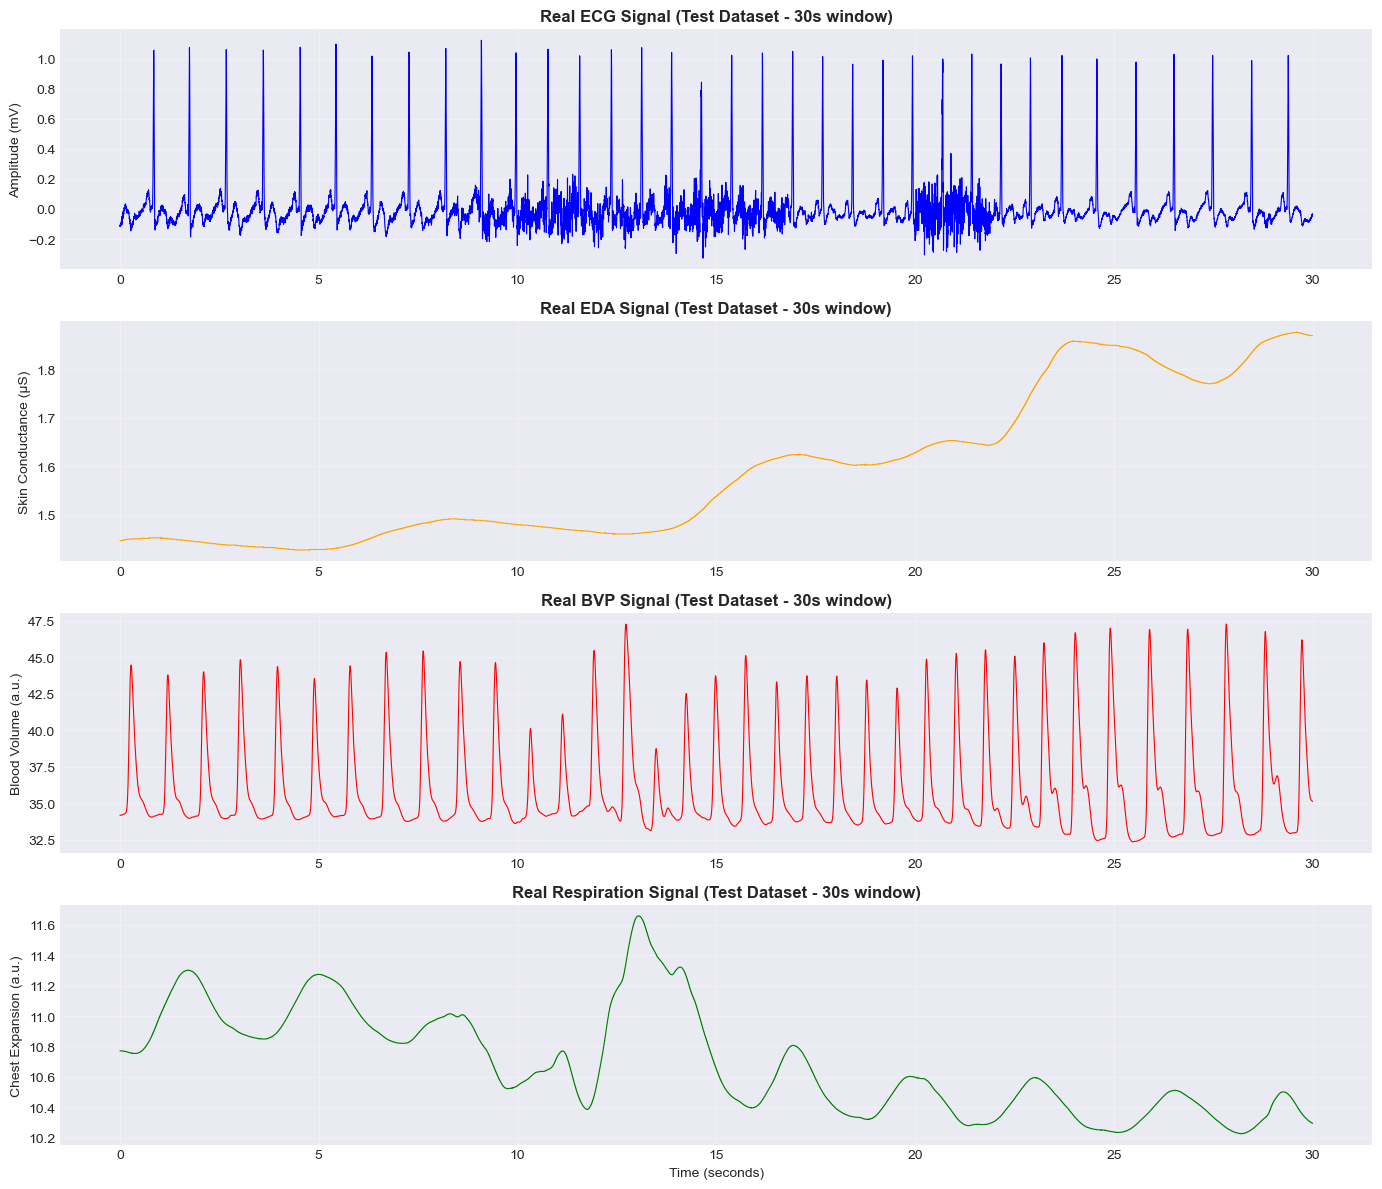

Real Test Data Statistics:
  - ECG: 245760 samples @ 2048 Hz
  - EDA: 245760 samples @ 2048 Hz
  - BVP: 245760 samples @ 2048 Hz
  - Respiration: 245760 samples @ 2048 Hz
  - Total duration: 120.0 seconds

  ECG stats: mean=-0.000, std=0.162
  EDA stats: mean=1.814, std=0.165
  BVP stats: mean=35.870, std=2.652
  Resp stats: mean=10.450, std=0.309


In [14]:
# Load multimodal signals from test dataset using generator methods
ecg = ECGGenerator.load_real_signal(return_signal=True)
eda = EDAGenerator.load_real_signal(return_signal=True)
bvp = BloodVolumePulseGenerator.load_real_signal(return_signal=True)
resp = RespirationGenerator.load_real_signal(return_signal=True)

# Display a 30-second window for clarity
fig, axes = plt.subplots(4, 1, figsize=(14, 12))

# Show first 30 seconds (at 2048 Hz, that's ~61,440 samples)
time_window = 30  # seconds
n_samples_window = int(time_window * 2048)

# ECG
axes[0].plot(ecg.time[:n_samples_window], ecg.values[:n_samples_window], 
            linewidth=0.8, color='blue')
axes[0].set_title('Real ECG Signal (Test Dataset - 30s window)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Amplitude (mV)')
axes[0].grid(True, alpha=0.3)

# EDA
axes[1].plot(eda.time[:n_samples_window], eda.values[:n_samples_window], 
            linewidth=0.8, color='orange')
axes[1].set_title('Real EDA Signal (Test Dataset - 30s window)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Skin Conductance (µS)')
axes[1].grid(True, alpha=0.3)

# BVP
axes[2].plot(bvp.time[:n_samples_window], bvp.values[:n_samples_window], 
            linewidth=0.8, color='red')
axes[2].set_title('Real BVP Signal (Test Dataset - 30s window)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Blood Volume (a.u.)')
axes[2].grid(True, alpha=0.3)

# Respiration
axes[3].plot(resp.time[:n_samples_window], resp.values[:n_samples_window], 
            linewidth=0.8, color='green')
axes[3].set_title('Real Respiration Signal (Test Dataset - 30s window)', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Chest Expansion (a.u.)')
axes[3].set_xlabel('Time (seconds)')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("Real Test Data Statistics:")
print(f"  - ECG: {len(ecg)} samples @ 2048 Hz")
print(f"  - EDA: {len(eda)} samples @ 2048 Hz")
print(f"  - BVP: {len(bvp)} samples @ 2048 Hz")
print(f"  - Respiration: {len(resp)} samples @ 2048 Hz")
print(f"  - Total duration: {len(ecg)/2048:.1f} seconds")
print(f"\n  ECG stats: mean={ecg.values.mean():.3f}, std={ecg.values.std():.3f}")
print(f"  EDA stats: mean={eda.values.mean():.3f}, std={eda.values.std():.3f}")
print(f"  BVP stats: mean={bvp.values.mean():.3f}, std={bvp.values.std():.3f}")
print(f"  Resp stats: mean={resp.values.mean():.3f}, std={resp.values.std():.3f}")

## 13. Comparing Synthetic vs Real Signals

Compare synthetic signals with real test data to understand signal characteristics and generation parameters.

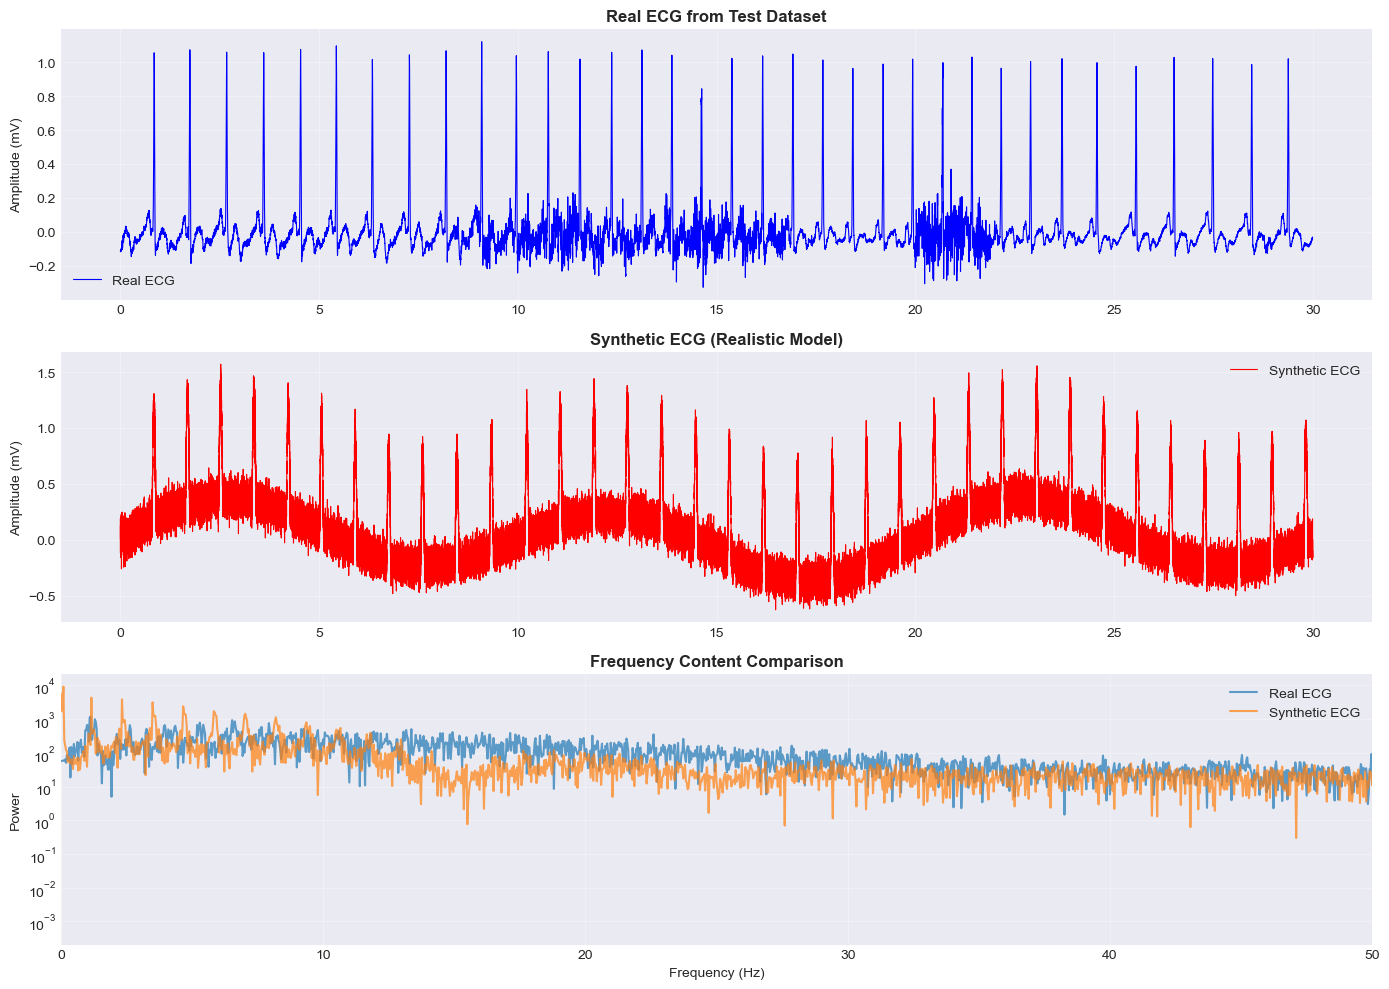


Signal Comparison:
Signal               Mean         Std Dev      Min          Max         
Real ECG             -0.0001      0.1617       -0.4530      1.1880      
Synthetic ECG        0.0952       0.3293       -0.6253      1.5705      


In [15]:
# Generate synthetic ECG and load real ECG for comparison
synthetic_ecg = ECGGenerator.realistic_ecg(
    duration=30,
    sampling_freq=2048,
    heart_rate=70,
    heart_rate_variability=15,
    noise_std=0.08
)
real_ecg = ECGGenerator.load_real_signal(return_signal=True)

# Visualize comparison
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Real ECG (first 30 seconds)
real_ecg_window = int(30 * 2048)
axes[0].plot(real_ecg.time[:real_ecg_window], real_ecg.values[:real_ecg_window], 
            linewidth=0.8, color='blue', label='Real ECG')
axes[0].set_title('Real ECG from Test Dataset', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Amplitude (mV)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Synthetic ECG (same duration)
axes[1].plot(synthetic_ecg.time, synthetic_ecg.values, 
            linewidth=0.8, color='red', label='Synthetic ECG')
axes[1].set_title('Synthetic ECG (Realistic Model)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Amplitude (mV)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Compare frequency content (FFT)
from scipy.fft import fft, fftfreq
real_fft = np.abs(fft(real_ecg.values[:real_ecg_window]))
synth_fft = np.abs(fft(synthetic_ecg.values))
freqs_real = fftfreq(real_ecg_window, 1/2048)[:real_ecg_window//2]
freqs_synth = fftfreq(len(synthetic_ecg), 1/2048)[:len(synthetic_ecg)//2]

axes[2].semilogy(freqs_real, real_fft[:real_ecg_window//2], 
                alpha=0.7, label='Real ECG', linewidth=1.5)
axes[2].semilogy(freqs_synth, synth_fft[:len(synthetic_ecg)//2], 
                alpha=0.7, label='Synthetic ECG', linewidth=1.5)
axes[2].set_title('Frequency Content Comparison', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Frequency (Hz)')
axes[2].set_ylabel('Power')
axes[2].set_xlim([0, 50])
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Compare statistics
print("\nSignal Comparison:")
print(f"{'Signal':<20} {'Mean':<12} {'Std Dev':<12} {'Min':<12} {'Max':<12}")
print("="*68)
print(f"{'Real ECG':<20} {real_ecg.values.mean():<12.4f} {real_ecg.values.std():<12.4f} {real_ecg.values.min():<12.4f} {real_ecg.values.max():<12.4f}")
print(f"{'Synthetic ECG':<20} {synthetic_ecg.values.mean():<12.4f} {synthetic_ecg.values.std():<12.4f} {synthetic_ecg.values.min():<12.4f} {synthetic_ecg.values.max():<12.4f}")

## Final Summary

This tutorial demonstrated the complete signal generation and analysis capabilities of PyPhysio:

### Synthetic Signal Generation
- **Basic Signals**: Sinusoidal, noise, fundamental patterns (zeros, ramps, impulses)
- **Physiological Signals**: ECG, respiration, EDA, BVP, fNIRS, EEG, EMG
- **Advanced Techniques**: Modulation, windowing, composite signals
- **Complex Waveforms**: Sawtooth, Gaussian, polynomial, frequency sweeps

### Real Test Data Integration
- **Multimodal Dataset**: 120 seconds of simultaneous ECG, EDA, BVP, and respiration (2048 Hz)
- **Neuroimaging Data**: fNIRS signals with and without motor tasks
- **Easy Loading**: Simple API through `RealTestDataGenerator` class

### Validation & Comparison
- Compare synthetic signals with real physiological data
- Analyze frequency content using FFT
- Validate signal parameters and generation algorithms
- Support for signal processing algorithm testing

### Key Features
✓ All signals returned as **xarray.DataArray** with full metadata  
✓ **Realistic physiological parameters** based on literature  
✓ **Flexible configuration** for any duration and sampling frequency  
✓ **Easy composition** for multi-modal signal generation  
✓ **Noise and artifact control** for algorithm testing  
✓ **Real test data** for validation and benchmarking  

### Use Cases
- Algorithm development and testing
- Signal processing validation
- Educational demonstrations
- Synthetic data generation for machine learning
- Physiological signal analysis
- Biomedical research

For more information, refer to the PyPhysio documentation and GitHub repository: https://github.com/BDAlab/pyphysio